Introduction:
This project analyzes US quarterly GDP growth data from 2010 through 2023 using three numerical methods: least squares linear regression, degree-4 polynomial fitting, and natural cubic spline interpolation. The dataset includes several major economic changes, including the large drop and rebound in GDP growth during the COVID-19 period. Each method serves a different purpose: linear regression is useful for identifying overall trends, polynomial fitting provides a smoother approximation of the data, and cubic splines allow for accurate interpolation between known points. By comparing these methods, it is possible to evaluate their strengths, weaknesses, and sensitivity to extreme values in the dataset.

Second derivative values at knots (M):
[ 0.00000000e+00  3.95919853e-01 -1.58679413e-01 -4.36202203e-01
  1.37848822e+00 -1.69852494e+00  1.09424311e-01  1.59416103e+00
 -3.63494160e+00  2.42132754e+00  1.14963145e+00 -2.27941050e+00
  7.74301054e+00 -3.19926317e+01  1.63254275e+02 -1.11624467e+02
  2.62962632e+01 -5.41405611e+00  1.78359147e+00  0.00000000e+00]

Maximum interpolation error at original data points:
5.329070518200751e-15

Spline values at every full quarter index:
Quarter index  1:   1.7000
Quarter index  2:   1.0526
Quarter index  3:   0.5041
Quarter index  4:   0.1536
Quarter index  5:   0.1000
Quarter index  6:   0.4027
Quarter index  7:   0.9628
Quarter index  8:   1.6414
Quarter index  9:   2.3000
Quarter index 10:   2.8115
Quarter index 11:   3.0949
Quarter index 12:   3.0809
Quarter index 13:   2.7000
Quarter index 14:   1.9701
Quarter index 15:   1.2577
Quarter index 16:   1.0164
Quarter index 17:   1.7000
Quarter index 18:   3.4300
Quarter index 19:   5.0000
Qu

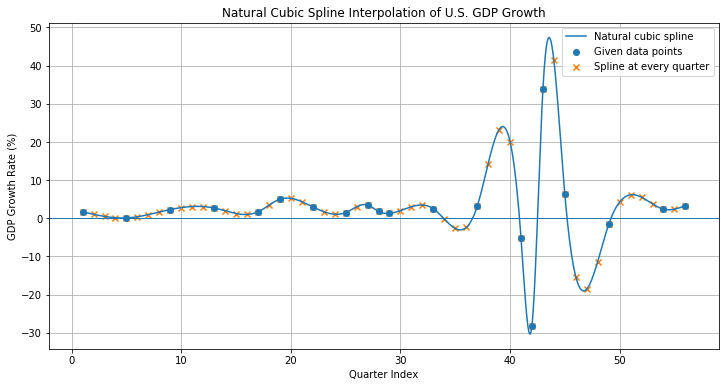

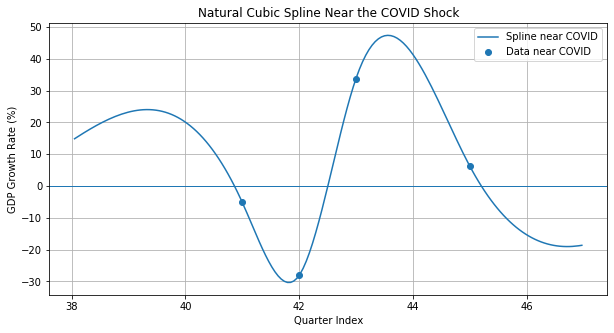

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# PART A: NATURAL CUBIC SPLINE INTERPOLATION


# 1. DATA SETUP

x = np.array([
    1,   # 2010 Q1
    5,   # 2011 Q1
    9,   # 2012 Q1
    13,  # 2013 Q1
    17,  # 2014 Q1
    19,  # 2014 Q3
    22,  # 2015 Q2
    25,  # 2016 Q1
    27,  # 2016 Q3
    28,  # 2016 Q4
    29,  # 2017 Q1
    33,  # 2018 Q1
    37,  # 2019 Q1
    41,  # 2020 Q1
    42,  # 2020 Q2
    43,  # 2020 Q3
    45,  # 2021 Q1
    49,  # 2022 Q1
    54,  # 2023 Q2
    56   # 2023 Q4
], dtype=float)

y = np.array([
    1.7,
    0.1,
    2.3,
    2.7,
    1.7,
    5.0,
    3.0,
    1.5,
    3.5,
    1.8,
    1.3,
    2.5,
    3.1,
    -5.1,
    -28.1,
    33.8,
    6.3,
    -1.6,
    2.4,
    3.3
], dtype=float)


# 2. THOMAS ALGORITHM FOR TRIDIAGONAL SYSTEMS

def thomas_algorithm(a, b, c, d):

    n = len(b)

    # Make copies
    ac = a.astype(float).copy()
    bc = b.astype(float).copy()
    cc = c.astype(float).copy()
    dc = d.astype(float).copy()

    for i in range(1, n):
        m = ac[i - 1] / bc[i - 1]
        bc[i] = bc[i] - m * cc[i - 1]
        dc[i] = dc[i] - m * dc[i - 1]

    # Back substitution
    x = np.zeros(n)
    x[-1] = dc[-1] / bc[-1]

    for i in range(n - 2, -1, -1):
        x[i] = (dc[i] - cc[i] * x[i + 1]) / bc[i]

    return x


# 3. BUILD NATURAL CUBIC SPLINE

def natural_cubic_spline_coefficients(x, y):
    
    n = len(x)
    h = np.diff(x)

    if n == 2:
        return np.zeros(2)

    system_size = n - 2

    a = np.zeros(system_size - 1) 
    b = np.zeros(system_size)      
    c = np.zeros(system_size - 1)  
    d = np.zeros(system_size)      

    for i in range(1, n - 1):
        row = i - 1

        h_left = h[i - 1]
        h_right = h[i]

        b[row] = 2 * (h_left + h_right)
        d[row] = 6 * (
            (y[i + 1] - y[i]) / h_right
            - (y[i] - y[i - 1]) / h_left
        )

        if row > 0:
            a[row - 1] = h_left
        if row < system_size - 1:
            c[row] = h_right

    M_interior = thomas_algorithm(a, b, c, d)

    M = np.zeros(n)
    M[1:n - 1] = M_interior

    return M


# 4. EVALUATE THE SPLINE AT ANY x_query

def evaluate_spline(x, y, M, x_query):
    
    x_query = np.atleast_1d(x_query).astype(float)
    s = np.zeros_like(x_query)

    for k, xq in enumerate(x_query):
        
        if xq <= x[0]:
            i = 0
        elif xq >= x[-1]:
            i = len(x) - 2
        else:
            
            i = np.searchsorted(x, xq) - 1

        h = x[i + 1] - x[i]

        term1 = M[i] * (x[i + 1] - xq) ** 3 / (6 * h)
        term2 = M[i + 1] * (xq - x[i]) ** 3 / (6 * h)
        term3 = (y[i] - M[i] * h ** 2 / 6) * (x[i + 1] - xq) / h
        term4 = (y[i + 1] - M[i + 1] * h ** 2 / 6) * (xq - x[i]) / h

        s[k] = term1 + term2 + term3 + term4

    if len(s) == 1:
        return s[0]

    return s


# 5. COMPUTE SPLINE

M = natural_cubic_spline_coefficients(x, y)

print("Second derivative values at knots (M):")
print(M)


# 6. VERIFY INTERPOLATION PROPERTY

y_check = evaluate_spline(x, y, M, x)
max_interp_error = np.max(np.abs(y_check - y))

print("\nMaximum interpolation error at original data points:")
print(max_interp_error)


# 7. EVALUATE SPLINE ON A DENSE GRID FOR SMOOTH PLOT

x_dense = np.linspace(x[0], x[-1], 1000)
y_dense = evaluate_spline(x, y, M, x_dense)


# 8. EVALUATE SPLINE AT EVERY QUARTER IN THE FULL RANGE

# From 2010 Q1 to 2023 Q4:
# 14 years * 4 quarters = 56 quarters (rubric says 55 but there are actually 56)
full_quarters = np.arange(1, 57, 1)
y_full = evaluate_spline(x, y, M, full_quarters)

print("\nSpline values at every full quarter index:")
for xi, yi in zip(full_quarters, y_full):
    print(f"Quarter index {int(xi):2d}: {yi:8.4f}")


# 9. PLOT THE SPLINE AND ORIGINAL DATA

plt.figure(figsize=(12, 6))
plt.scatter(x, y, label="Given data points", zorder=3)
plt.plot(x_dense, y_dense, label="Natural cubic spline")
plt.scatter(full_quarters, y_full, marker='x', label="Spline at every quarter")

plt.axhline(0, linewidth=1)
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Natural Cubic Spline Interpolation of U.S. GDP Growth")
plt.legend()
plt.grid(True)
plt.show()


# 10. NOT REQUIRED: PLOT JUST THE COVID REGION TO SEE LOCAL BEHAVIOR

covid_mask_dense = (x_dense >= 38) & (x_dense <= 47)
covid_mask_points = (x >= 38) & (x <= 47)

plt.figure(figsize=(10, 5))
plt.scatter(x[covid_mask_points], y[covid_mask_points], label="Data near COVID", zorder=3)
plt.plot(x_dense[covid_mask_dense], y_dense[covid_mask_dense], label="Spline near COVID")
plt.axhline(0, linewidth=1)
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Natural Cubic Spline Near the COVID Shock")
plt.legend()
plt.grid(True)
plt.show()

Part A-1:
To construct the natural cubic spline, I used consecutive integer quarter indices as the independent variable, beginning with 2010 Q1 = 1 and ending with 2023 Q4 = 56. For a number n of data points, the splines consists of n - 1 cubic polynomials, one on each interval between consecutive data points.

Rather than solving for every 4(n - 1) cubic coefficients, I used the standard second-derivative formulation. Here, the unknowns are the second derivatives at the interior knots:

M(sub1), M(sub2), ..., M(sub(n-2))

Since the endpoint second derivatives are fixed by natural boundary conditions:

M(sub0) = 0, M(sub(n-1)) = 0

there are only n - 2 unknowns.

For each interior knot x(sub(i)), the second derivatives satisfy the tridiagonal spline equation:

h(sub(i-1)) x M(sub(i-1)) + 2(h(sub(i-1)) + h(sub(i))) x M(sub(i)) + h(sub(i)) x M(sub(i+1))

= 

6( ((y(sub(i+1))-y(sub(i))/h(sub(i))) - ((y(sub(i)) - y(sub(i-1)))/h(sub(i-1)) )

where h(sub(i)) = x(sub(i+1)) - x(sub(i)) represent the spacing between adjacent quarter indices. Since the quarter indices are not evenly spaced in the selected dataset, the values of h(sub(i)) can vary depending on the gap between known quarters. Solving the tridiagonal system gives the second derivatives at the interior knots, which are then used to make each cubic spline segment.

Therefore, the resulting tridiagonal linear system has size (n - 2) x (n - 2)

At each interior knot, the spline satisfies three continuity conditions:

C0 : S(sub(i-1))(x(sub(i))) = S(sub(i))(x(sub(i)))
or more explicitly stated, S sub i-1 of x sub i is equal to S sub i of x sub i.

C1 : S'(sub(i-1))(x(sub(i))) = S'(sub(i))(x(sub(i)))
or more explicitly stated, S prime sub i-1 of x sub i is equal to S prime sub i of x sub i.

C2 : S''(sub(i-1))(x(sub(i))) = S''(sub(i))(x(sub(i)))
or more explicitly stated, S double prime sub i-1 of x sub i is equal to S double prime sub i of x sub i.

These conditions ensure that the spline is continuous, has continuous slope, and has continuous curvature at each interior knot.

The natural boundary conditions:

S''(x(sub0)) = 0, S''(x(sub(n-1))) = 0

make the spline "natural" by forcing curvature to vanish at the endpoints. This produces a smooth interpolant that passes precisely through the provided GDP data points.

Part A-3:
The main limitation of exact interpolation is that the interpolating curve must pass through every data point, even if some points are extreme outliers. In this dataset, the COVID-era values in 2020 Q2 and 2020 Q3 are unusually large in magnitude compared to the rest of the GDP growth values. Because the spline must pass exactly through these points, the curve develops very large curvature near those quarters.

The Runge phenomenon refers to the large oscillations that can occur when using a single high-degree polynomial to interpolate many data points exactly. These oscillations are often especially severe near the ends of the interval. If a high-degree polynomial interpolant were used for this GDP dataset, the COVID outliers would likely create unrealistic oscillations across the entire time range.

Cubic splines are less sensitive to Runge phenomenon because they use many local low-degree polynomials instead of one global high-degree polynomial. As a result, the spline remains stable and smooth across most of the interval, with distortion occurring mainly near the outlier region.

However, even cubic splines can still be affected locally by extreme data points because they must interpolate exactly. If the goal is to estimate the long-term economic trend rather than reproduce every quarterly fluctuation exactly, a smoothing spline or weighted least squares model may be preferable.

A smoothing spline would allow a trade-off between fitting the data and maintaining smoothness, while weighted least squares would reduce the influence of unusually large COVID-period values on the fitted trend. These methods would likely provide a more stable representation of overall GDP growth behavior.


Degree-4 polynomial coefficients [c0, c1, c2, c3, c4]:
[ 2.11403340e-01  4.12733208e-01 -2.11036921e-02  3.57892276e-04
 -1.71060095e-06]

Condition number of A^T A for degree-4 polynomial:
331159708504818.56

Degree-4 polynomial RMSE on provided data:
10.031440678677116


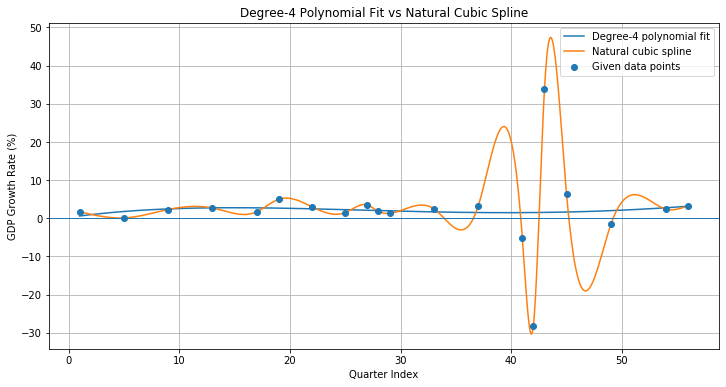

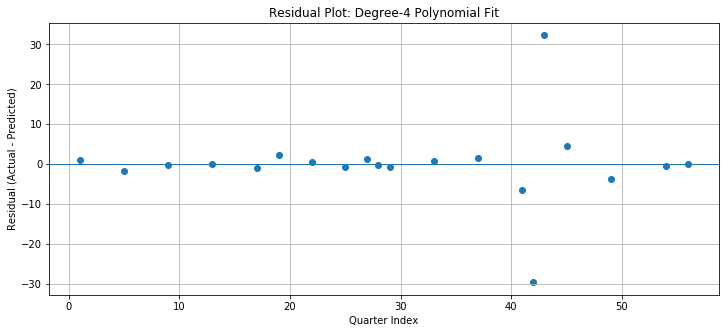


Linear model coefficients excluding 2020 Q1–2021 Q1:
Intercept = 2.194285187007874
Slope     = -0.0019069881889763796

Condition number of A^T A for linear fit:
3605.5885513928274

Linear fit RMSE excluding COVID quarters:
1.4431864883291987


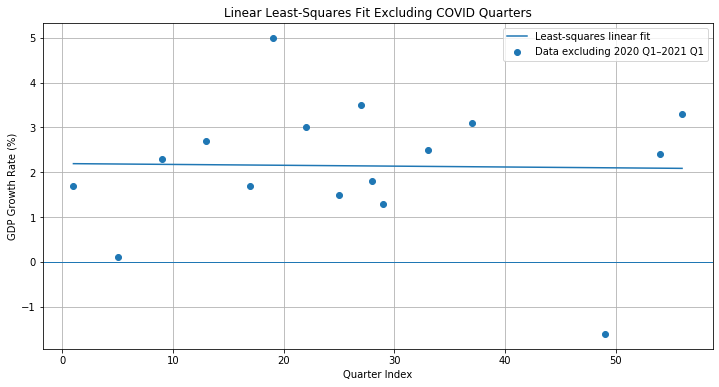

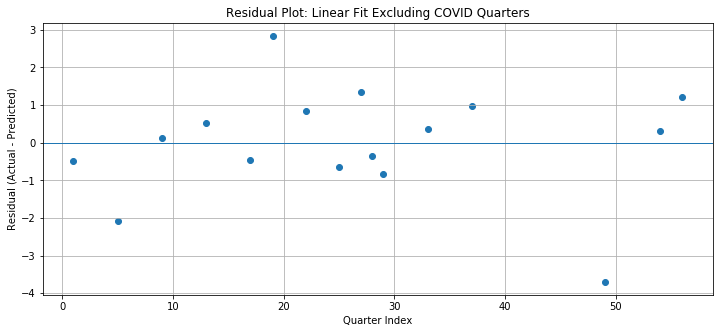


Degree-4 Polynomial Fit: Actual vs Predicted
x =  1, actual =    1.70, predicted =    0.6034, residual =    1.0966
x =  5, actual =    0.10, predicted =    1.7911, residual =   -1.6911
x =  9, actual =    2.30, predicted =    2.4663, residual =   -0.1663
x = 13, actual =    2.70, predicted =    2.7478, residual =   -0.0478
x = 17, actual =    1.70, predicted =    2.7444, residual =   -1.0444
x = 19, actual =    5.00, predicted =    2.6668, residual =    2.3332
x = 22, actual =    3.00, predicted =    2.4875, residual =    0.5125
x = 25, actual =    1.50, predicted =    2.2638, residual =   -0.7638
x = 27, actual =    3.50, predicted =    2.1059, residual =    1.3941
x = 28, actual =    1.80, predicted =    2.0277, residual =   -0.2277
x = 29, actual =    1.30, predicted =    1.9512, residual =   -0.6512
x = 33, actual =    2.50, predicted =    1.6826, residual =    0.8174
x = 37, actual =    3.10, predicted =    1.5140, residual =    1.5860
x = 41, actual =   -5.10, predicted =    1.4

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# PART B: POLYNOMIAL & LEAST SQUARES COMPARISON


# 1. HELPER: BUILD VANDERMONDE MATRIX

def vandermonde_matrix(x, degree):
    
    x = np.asarray(x, dtype=float)
    n = len(x)
    V = np.zeros((n, degree + 1))

    for j in range(degree + 1):
        V[:, j] = x ** j

    return V


# 2. HELPER: RMSE

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


# 3. DEGREE-4 POLYNOMIAL FIT USING LEAST SQUARES NORMAL EQUATIONS

def polynomial_least_squares_fit(x, y, degree):
    
    A = vandermonde_matrix(x, degree)
    ATA = A.T @ A
    ATy = A.T @ y
    coeffs = np.linalg.solve(ATA, ATy)
    return coeffs, A, ATA


def evaluate_polynomial(coeffs, x_vals):
    
    x_vals = np.asarray(x_vals, dtype=float)
    y_vals = np.zeros_like(x_vals)

    for j in range(len(coeffs)):
        y_vals += coeffs[j] * (x_vals ** j)

    return y_vals


# 4. LINEAR LEAST SQUARES FIT

def linear_least_squares_fit(x, y):
    
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    A = np.column_stack((np.ones(len(x)), x))
    ATA = A.T @ A
    ATy = A.T @ y
    coeffs = np.linalg.solve(ATA, ATy)

    return coeffs, A, ATA


# 5. PART B.1 — DEGREE-4 POLYNOMIAL FIT TO FULL DATA

degree = 4
poly_coeffs, A_poly, ATA_poly = polynomial_least_squares_fit(x, y, degree)

print("Degree-4 polynomial coefficients [c0, c1, c2, c3, c4]:")
print(poly_coeffs)

poly_cond_number = np.linalg.cond(ATA_poly)
print("\nCondition number of A^T A for degree-4 polynomial:")
print(poly_cond_number)

# Predictions on the original data points
y_poly_at_data = evaluate_polynomial(poly_coeffs, x)
poly_rmse = rmse(y, y_poly_at_data)

print("\nDegree-4 polynomial RMSE on provided data:")
print(poly_rmse)

x_dense = np.linspace(x[0], x[-1], 1000)
y_poly_dense = evaluate_polynomial(poly_coeffs, x_dense)

# Spline from Part A
# Requires that Part A code has already been run
M = natural_cubic_spline_coefficients(x, y)
y_spline_dense = evaluate_spline(x, y, M, x_dense)

poly_residuals = y - y_poly_at_data

plt.figure(figsize=(12, 6))
plt.scatter(x, y, label="Given data points", zorder=3)
plt.plot(x_dense, y_poly_dense, label="Degree-4 polynomial fit")
plt.plot(x_dense, y_spline_dense, label="Natural cubic spline")
plt.axhline(0, linewidth=1)
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Degree-4 Polynomial Fit vs Natural Cubic Spline")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.scatter(x, poly_residuals)
plt.axhline(0, linewidth=1)
plt.xlabel("Quarter Index")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot: Degree-4 Polynomial Fit")
plt.grid(True)
plt.show()


# 6. PART B.2 — LINEAR MODEL EXCLUDING COVID QUARTERS
# Exclude 2020 Q1 through 2021 Q1 inclusive:
# 2020 Q1 = 41
# 2020 Q2 = 42
# 2020 Q3 = 43
# 2020 Q4 = 44
# 2021 Q1 = 45

mask_no_covid = (x < 41) | (x > 45)

x_no_covid = x[mask_no_covid]
y_no_covid = y[mask_no_covid]

lin_coeffs, A_lin, ATA_lin = linear_least_squares_fit(x_no_covid, y_no_covid)

b0 = lin_coeffs[0]
b1 = lin_coeffs[1]

print("\nLinear model coefficients excluding 2020 Q1–2021 Q1:")
print(f"Intercept = {b0}")
print(f"Slope     = {b1}")

lin_cond_number = np.linalg.cond(ATA_lin)
print("\nCondition number of A^T A for linear fit:")
print(lin_cond_number)

y_lin_at_data = b0 + b1 * x_no_covid
lin_rmse = rmse(y_no_covid, y_lin_at_data)

print("\nLinear fit RMSE excluding COVID quarters:")
print(lin_rmse)

lin_residuals = y_no_covid - y_lin_at_data

x_line = np.linspace(np.min(x_no_covid), np.max(x_no_covid), 500)
y_line = b0 + b1 * x_line

plt.figure(figsize=(12, 6))
plt.scatter(x_no_covid, y_no_covid, label="Data excluding 2020 Q1–2021 Q1", zorder=3)
plt.plot(x_line, y_line, label="Least-squares linear fit")
plt.axhline(0, linewidth=1)
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Linear Least-Squares Fit Excluding COVID Quarters")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.scatter(x_no_covid, lin_residuals)
plt.axhline(0, linewidth=1)
plt.xlabel("Quarter Index")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot: Linear Fit Excluding COVID Quarters")
plt.grid(True)
plt.show()


# 7. NOT REQUIRED: PRINT TABLE OF ACTUAL VS PREDICTED VALUES

print("\nDegree-4 Polynomial Fit: Actual vs Predicted")
for xi, yi, yhat in zip(x, y, y_poly_at_data):
    print(f"x = {int(xi):2d}, actual = {yi:7.2f}, predicted = {yhat:9.4f}, residual = {yi - yhat:9.4f}")

print("\nLinear Fit Excluding COVID Quarters: Actual vs Predicted")
for xi, yi, yhat in zip(x_no_covid, y_no_covid, y_lin_at_data):
    print(f"x = {int(xi):2d}, actual = {yi:7.2f}, predicted = {yhat:9.4f}, residual = {yi - yhat:9.4f}")

Part B-1:
I fit a degree-4 polynomial to the full GDP dataset using least squares. Unlike the spline, the polynomial does not pass exactly through every point. Instead, it minimizes the overall squared error across the dataset.

The degree-4 polynomial captures the general trend of the GDP data, but it smooths over many of the smaller local changes. In particular, it does not match the extreme COVID-era values as closely as the spline.

The cubic spline better reproduces the exact data points because it passes through every point exactly, including the large drop in 2020 Q2 and rebound in 2020 Q3. However, because of this exact interpolation, the spline is also more sensitive to local outliers.

Overall, the spline is better for capturing local behavior and specific data points, while the polynomial is better for showing the broader trend in GDP growth.

Part B-2:
I also fit a least squares linear model after excluding the quarters from 2020 Q1 through 2021 Q1. These quarters were removed because the COVID period caused unusually large changes in GDP growth that would distort the long-term trend.

The linear model had the form:

y = b(sub(0)) + x (b(sub(1))) , where b(sub(0)) is the intercept and b(sub(1)) is the slope.

The slope of the of the fitted line was -0.0019069881889763796

A positive slope of course indicates that GDP growth increased over time, while a negative slope would indicate a long-term decrease.

Although the least squares linear model is simple and easy to interpret, it is not a particularly realistic model for GDP growth. Economic growth rates fluctuate significantly over time due to recessions, recoveries, inflation, government policy, and major external shocks such as COVID-19. A linear model assumes that GDP growth changes at a constant rate over time, which is not fully consistent with the cyclical nature of the economy.

For a fully linear trend to make sense, it requires several assumptions:

-GDP growth changes approximately linearly over time
-Random fluctuations are relatively small
-There are no major structural breaks or shocks
-The relationship between time and GDP growth remains stable throughout the interval

These assumptions are not fully satisfied in this dataset because GDP growth is obviously realistic (since it is real) and contains periods of recession, expansion, and pandemic-related shifts. Therefore, the linear model is best seen as a general "summary" of the overall trend rather than a highly accurate predictive model.

Part C:
For a policymaker who needs to estimate GDP growth between two known quarters, I would recommend the natural cubic spline.

The spline is a better choice for interpolation because it passes exactly through every known data points while remaining smooth between them. It also has continuous first and second derivatives, so the curve does not have jump discontinuities or kinks.

A polynomial fit is better for approximating the overall trend of the data, but it may not match the local behavior between nearby quarters very well. High-degree polynomials can also become unstable and oscillate, especially when the dataset contains large outliers such as the COVID era GDP values.

Because the policymaker wants an estimate between known data points rather than a broad long-term trend, the spline is the more accurate and reliable method. It captures local changes more effectively and is less sensitive to global oscillations than a single polynomial fit.

Part C Addendum:

Big O notation is used to describe how the computational cost of an algorithm grows as the size of the input increases. In this project, the input size is the number of data points n.

For the linear least squares model, the matrices are very small, so the computational cost is low. Solving the normal equations for a linear fit is approximately O(n) because only a few sums need to be computed.

For the degree-4 polynomial fit, building the Vandermonde matrix is approximately O(n) since the polynomial degree is fixed. Solving the resulting 5 x 5 normal equation system is effectively constant time, so the overall complexity is also approximately
O(n) for this project.

For the natural cubic spline, constructing the tridiagonal system is O(n) and solving it with Thomas's algorithm is also O(n) because each row is only visited once during forward elimination and back substitution.

Since all three methods are approximately linear in n for this project, the computational complexity does not significantly affect the recommendation. The spline is still the best method for interpolation because it gives the most accurate estimates between known points while remaining smooth and stable.

If the dataset became extremely large, the spline would still remain efficient because the tridiagonal system can be solved quickly, while higher-degree polynomial fits could become more computationally expensive and numerically unstable.

Overall, the natural cubic spline performed best for interpolation because it passed exactly through all known GDP data points while remaining smooth between them. The degree-4 polynomial fit was better for showing the broader trend in the data, although it did not capture local fluctuations as accurately as the spline. The linear model was useful for identifying a rough long-term trend after removing the COVID-era quarters, but it was not detailed enough to represent the full variability of GDP growth. This project showed that interpolation methods are better for estimating values between known data points, while least squares methods are more useful for identifying overall trends. It also demonstrated how extreme outliers can affect fitted models and why choosing the appropriate numerical method depends on the specific goal of the analysis.